# NYC Yellow Taxi 데이터 시각화 분석 (2026-05)

본 노트북은 팀원들이 개별 파일로 분산하여 작업한 시각화 코드들을 통합하고 정비한 문서입니다.

### 분석 내용:
- **정적 시각화 (Seaborn)**:
  1. 시간대별 택시 이용량 (막대그래프)
  2. 승객 수별 평균 팁 금액 (색상 테마 막대그래프)
  3. 시간대별(출근, 낮, 퇴근, 심야) 평균 팁 금액 (막대그래프)
  4. 주요 변수 간 상관행렬 히트맵 (상관성 직관적 파악)
- **인터랙티브 시각화 (Plotly Express)**:
  1. 시간대별 택시 이용량 (동적 막대그래프)
  2. 시간대별 평균 팁 금액 (동적 막대그래프)
  3. 주행 거리 vs 기본 요금 산점도 (10,000건 샘플링을 적용해 쾌적한 브라우징 보장 및 요금제별 색상 코딩)

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os
import platform

### 폰트 설정 및 Seaborn 테마 로딩
- 한글이 포함된 그래프 제목이나 축 레이블이 깨지지 않도록 Windows(`Malgun Gothic`) 및 Mac(`AppleGothic`) 운영체제 맞춤 폰트를 적용합니다.

In [2]:
# Seaborn 테마 설정
sns.set_theme(style="whitegrid")

# OS별 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # Mac
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

### 데이터 로드
- 분석 대상 파일은 전처리가 완료된 `yellow_tripdata_2026-05_clean.parquet` 입니다.
- 일부 환경에서 `pd.read_parquet()` 호출 시 PyArrow 확장 타입 버그(`ArrowKeyError`)가 발생하므로, `pq.read_table().to_pandas()`로 직접 변환하여 로드합니다.

In [3]:
DATA_PATH = "../data/yellow_tripdata_2026-05_clean.parquet"
df = pq.read_table(DATA_PATH).to_pandas()
print(f"[데이터 로드 완료] 행: {len(df):,}  열: {df.shape[1]}")

[데이터 로드 완료] 행: 2,877,997  열: 26


---
## 1. 정적 시각화 (Seaborn)

### 1-1. 시간대별 택시 이용량
- 택시 수요가 특정 시간에 얼마나 쏠리는지 관찰합니다.

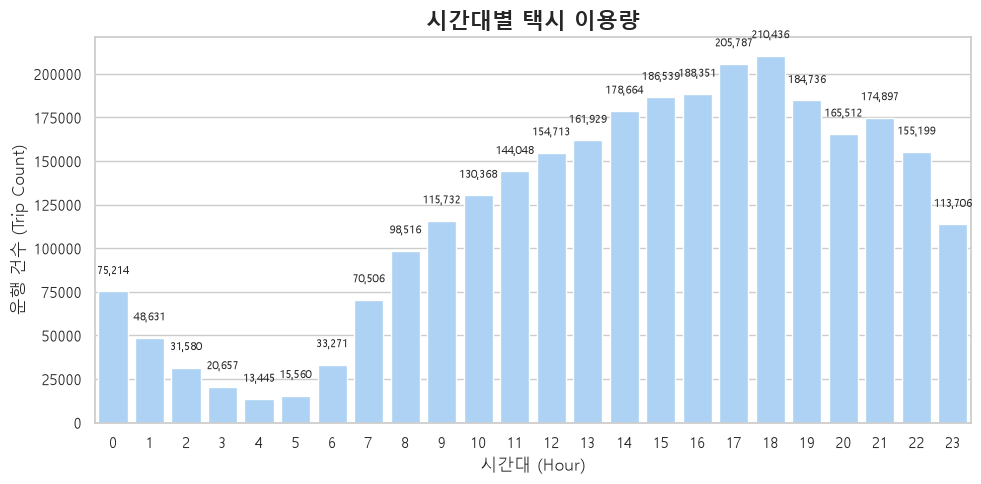

In [4]:
hour_df = df.groupby("pickup_hour").size().reset_index(name="trip_count")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=hour_df,
    x="pickup_hour",
    y="trip_count",
    color="#A2D2FF"
)

# 막대 위에 값 수치 텍스트 표시
for i, value in enumerate(hour_df["trip_count"]):
    ax.text(
        i,
        value + 10000,
        f"{value:,}",
        ha="center",
        fontsize=8
    )

plt.title("시간대별 택시 이용량", fontsize=16, fontweight="bold")
plt.xlabel("시간대 (Hour)")
plt.ylabel("운행 건수 (Trip Count)")
plt.tight_layout()

os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/taxi_demand_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

### 1-2. 탑승 승객 수별 평균 팁 금액
- 승객 수(1~6명)에 맞춰 평균적으로 팁을 지출하는 수준이 다른지 비교합니다.

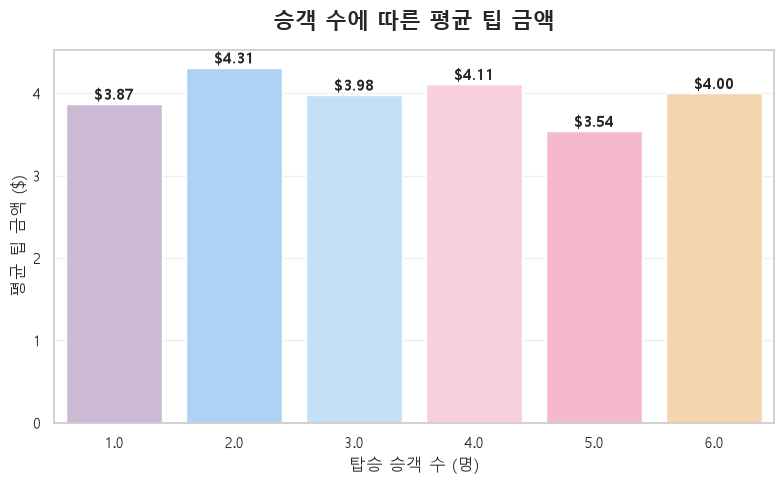

In [5]:
tip_passenger_df = df.groupby("passenger_count").agg(avg_tip=("tip_amount", "mean")).reset_index()
tip_passenger_df["avg_tip"] = tip_passenger_df["avg_tip"].round(2)

plt.figure(figsize=(8, 5))
colors = ["#CDB4DB", "#A2D2FF", "#BDE0FE", "#FFC8DD", "#FFAFCC", "#FFD6A5"]
ax = sns.barplot(
    data=tip_passenger_df,
    x="passenger_count",
    y="avg_tip",
    palette=colors,
    hue="passenger_count",
    legend=False
)

# 막대 위에 평균 팁 값 금액 표시
for i, value in enumerate(tip_passenger_df["avg_tip"]):
    ax.text(
        i,
        value + 0.05,
        f"${value:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("승객 수에 따른 평균 팁 금액", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("탑승 승객 수 (명)")
plt.ylabel("평균 팁 금액 ($)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/tip_by_passenger_count.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

### 1-3. 주요 시간대별 평균 팁 금액
- 하루 시간대를 출근, 낮, 퇴근, 심야 구간으로 묶어 팁 지급 현황을 파악합니다.

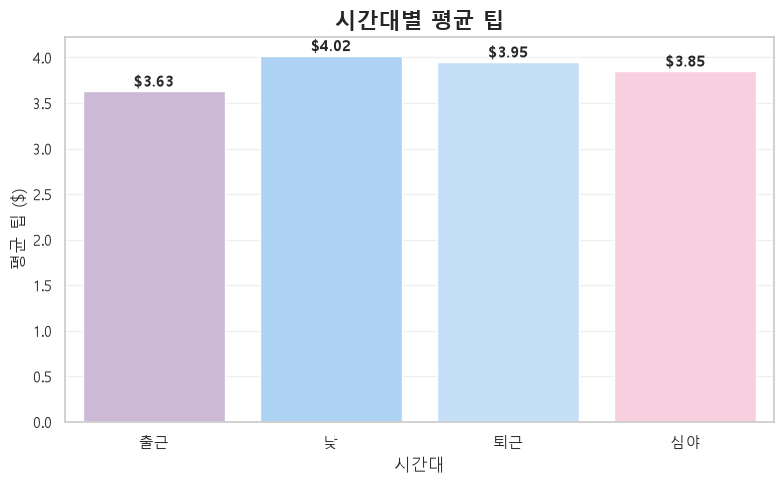

In [6]:
period_labels = {
    "morning_rush": "출근",
    "daytime": "낮",
    "evening_rush": "퇴근",
    "night": "심야"
}
df["period_label"] = df["time_period"].map(period_labels)

tip_df = (
    df.groupby("period_label", observed=True)["tip_amount"]
    .mean()
    .reindex(["출근", "낮", "퇴근", "심야"])
    .reset_index()
)
tip_df.columns = ["시간대", "평균팁"]
tip_df["평균팁"] = tip_df["평균팁"].round(2)

plt.figure(figsize=(8, 5))
colors = ["#CDB4DB", "#A2D2FF", "#BDE0FE", "#FFC8DD"]
ax = sns.barplot(
    data=tip_df,
    x="시간대",
    y="평균팁",
    hue="시간대",
    palette=colors,
    legend=False
)

for i, value in enumerate(tip_df["평균팁"]):
    ax.text(
        i,
        value + 0.05,
        f"${value:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("시간대별 평균 팁", fontsize=16, fontweight="bold")
plt.xlabel("시간대")
plt.ylabel("평균 팁 ($)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/avg_tip_by_period.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

### 1-4. 상관행렬 히트맵
- 통계 파트에서 구해질 각 수치형 컬럼 간 피어슨 상관계수를 히트맵으로 한눈에 파악합니다.

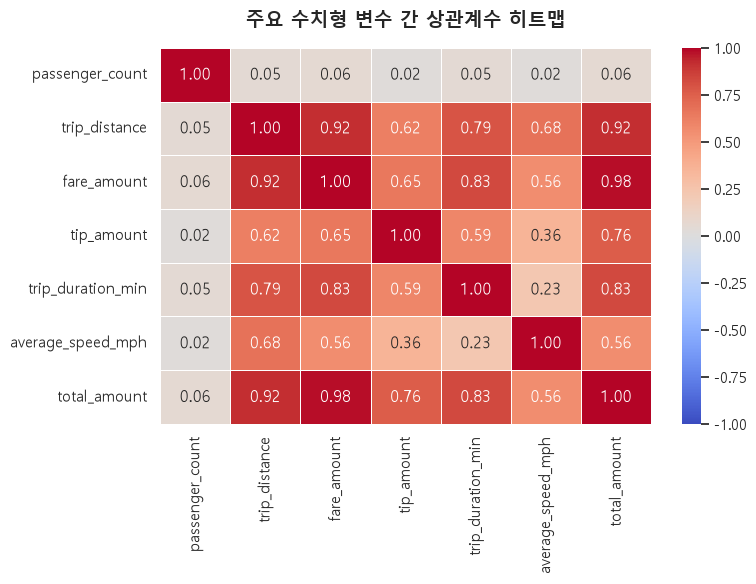

In [7]:
numeric_cols = ["passenger_count", "trip_distance", "fare_amount", "tip_amount", "trip_duration_min", "average_speed_mph", "total_amount"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("주요 수치형 변수 간 상관계수 히트맵", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../outputs/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

---
## 2. 동적 시각화 (Plotly Express)

### 2-1. 시간대별 택시 이용량 (Interactive)

In [8]:
fig = px.bar(
    hour_df,
    x="pickup_hour",
    y="trip_count",
    title="시간대별 택시 이용량 (Interactive)",
    labels={"pickup_hour": "시간대", "trip_count": "운행 건수"},
    text="trip_count"
)
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(width=900, height=500, xaxis_title="시간대", yaxis_title="운행 건수")
fig.show()
fig.write_html("../outputs/taxi_demand_by_hour_interactive.html")

### 2-2. 시간대별 평균 팁 (Interactive)

In [9]:
fig = px.bar(
    tip_df,
    x="시간대",
    y="평균팁",
    title="시간대별 평균 팁 금액 (Interactive)",
    labels={"시간대": "시간대", "평균팁": "평균 팁($)"},
    text="평균팁"
)
fig.update_traces(texttemplate="$%{text}", textposition="outside")
fig.update_layout(width=900, height=500, xaxis_title="시간대", yaxis_title="평균 팁($)")
fig.show()
fig.write_html("../outputs/avg_tip_by_period_interactive.html")

### 2-3. 주행 거리 vs 기본 요금 산점도 (Interactive Scatter with Sampling)
- 전체 데이터가 대량이므로 웹브라우저 가속을 보장하기 위해 **10,000건 무작위 샘플링**을 취합니다.
- `RatecodeID`를 범주(문자열)로 변환해 색상별 요금 규정을 직관적으로 파악합니다.

In [10]:
# 10,000건 무작위 추출
df_sample = df.sample(n=10000, random_state=42).copy()
df_sample["RatecodeID_str"] = df_sample["RatecodeID"].astype(str)

fig = px.scatter(
    df_sample,
    x="trip_distance",
    y="fare_amount",
    color="RatecodeID_str",
    title="주행 거리 vs 기본 요금 분포 (Interactive - 10k Samples)",
    labels={
        "trip_distance": "주행 거리 (마일)",
        "fare_amount": "기본 요금 ($)",
        "RatecodeID_str": "요금제 코드 (Ratecode)"
    },
    hover_data=["passenger_count", "trip_duration_min", "total_amount"],
    opacity=0.6
)
fig.update_layout(width=900, height=600)
fig.show()
fig.write_html("../outputs/trip_distance_vs_fare_interactive.html")